1. Understand: Why Position Matters Without Recurrence
    - Before Transformers, models like RNNs and LSTMs processed language sequentially. They read word $t$, updated their hidden state, and then moved to word $t+1$. The order of the words was inherently baked into the architecture because time steps were processed sequentially.
    
    - The Transformer Problem:
        - The Transformer abandons recurrence entirely in favor of processing all words in a sequence simultaneously (in parallel).If you feed a standard Self-Attention mechanism the sentences:
        
        "The dog chased the cat"
        
        "The cat chased the dog"
        
        - To the model, these are just "bags of words." Without a sense of position, the Self-Attention mechanism computes the exact same attention scores for the words in both sentences. It wouldn't know who is chasing whom.
    
    - The Solution:
        - Since the architecture doesn't have a built-in sense of order, we have to manually inject a "positional stamp" into the input data itself. We do this by taking the original word embedding and adding a Positional Encoding vector to it before it enters the first Transformer block.$$\text{Input} = \text{Word Embedding} + \text{Positional Encoding}$$

2. Deep Dive: The Positional Encoding Math
    - The authors of the paper needed a way to create a unique positional stamp for every single position in a sentence. They chose sine and cosine functions of different frequencies.
    - Here is the famous formula:
                $$
                PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)
                $$
                $$
                PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)
                $$
    - What do these variables mean?
        - $pos$: The position of the word in the sequence (e.g., the first word is $pos=0$, the second is $pos=1$).
        - $i$: The dimension index of the embedding (from $0$ to $d_{\text{model}}/2$).
        - $d_{\text{model}}$: The total size of the embedding vector (e.g., $512$ in the original paper).

3. The formula for positional encoding is described in the paper (section 3.5). You can see the code for generating positional encodings in get_timing_signal_1d(). This is not the only possible method for positional encoding. It, however, gives the advantage of being able to scale to unseen lengths of sequences (e.g. if our trained model is asked to translate a sentence longer than any of those in our training set).

In [1]:
import math
import torch
import torch.nn as nn

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len = 5000, dropout = 0.1):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p = dropout)

        pe = torch.zeros(max_len, d_model)
        position  =  torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


if __name__ == "__main__":
    d_model = 512
    seq_len = 10
    batch_size = 2

    x = torch.zeros(batch_size, seq_len, d_model)
    pos_encoder = PositionalEncoding(d_model)

    output = pos_encoder(x)

    print(f"Input shape: {x.shape}")
    print(f"Output shape: {output.shape}")

Input shape: torch.Size([2, 10, 512])
Output shape: torch.Size([2, 10, 512])



--- First few rows of sinusoidal positional encoding matrix ---
tensor([[ 0.0000,  1.0000,  0.0000,  1.0000,  0.0000,  1.0000,  0.0000,  1.0000,
          0.0000,  1.0000],
        [ 0.8415,  0.5403,  0.6816,  0.7318,  0.5332,  0.8460,  0.4093,  0.9124,
          0.3110,  0.9504],
        [ 0.9093, -0.4161,  0.9975,  0.0709,  0.9021,  0.4315,  0.7469,  0.6649,
          0.5911,  0.8066],
        [ 0.1411, -0.9900,  0.7783, -0.6279,  0.9933, -0.1160,  0.9536,  0.3010,
          0.8126,  0.5828],
        [-0.7568, -0.6536,  0.1415, -0.9899,  0.7785, -0.6277,  0.9933, -0.1157,
          0.9536,  0.3011],
        [-0.9589,  0.2837, -0.5711, -0.8209,  0.3239, -0.9461,  0.8589, -0.5121,
          0.9999, -0.0103],
        [-0.2794,  0.9602, -0.9774, -0.2114, -0.2304, -0.9731,  0.5740, -0.8188,
          0.9471, -0.3208],
        [ 0.6570,  0.7539, -0.8593,  0.5114, -0.7137, -0.7004,  0.1886, -0.9821,
          0.8004, -0.5994]])


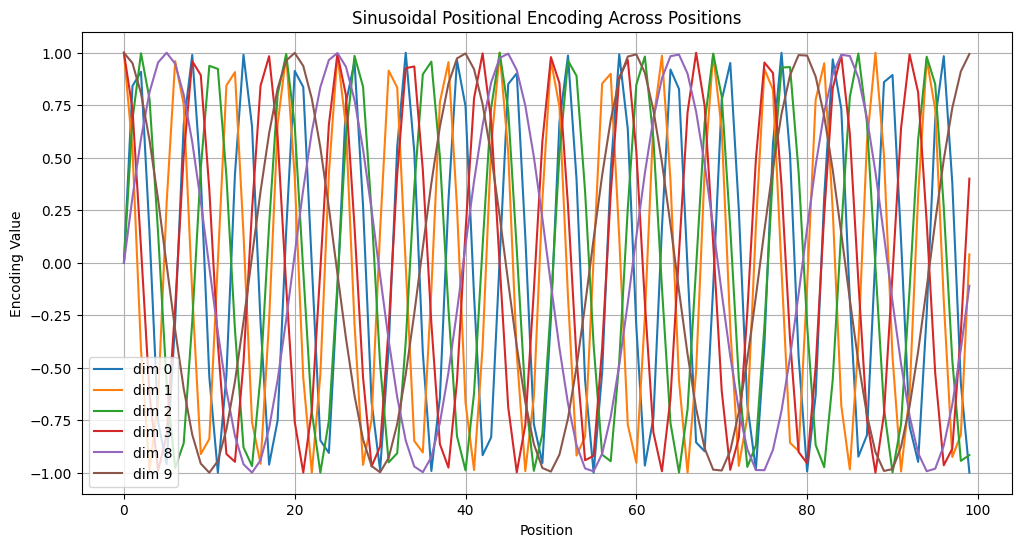


--- Comparing sinusoidal encoding with learned positional embeddings ---


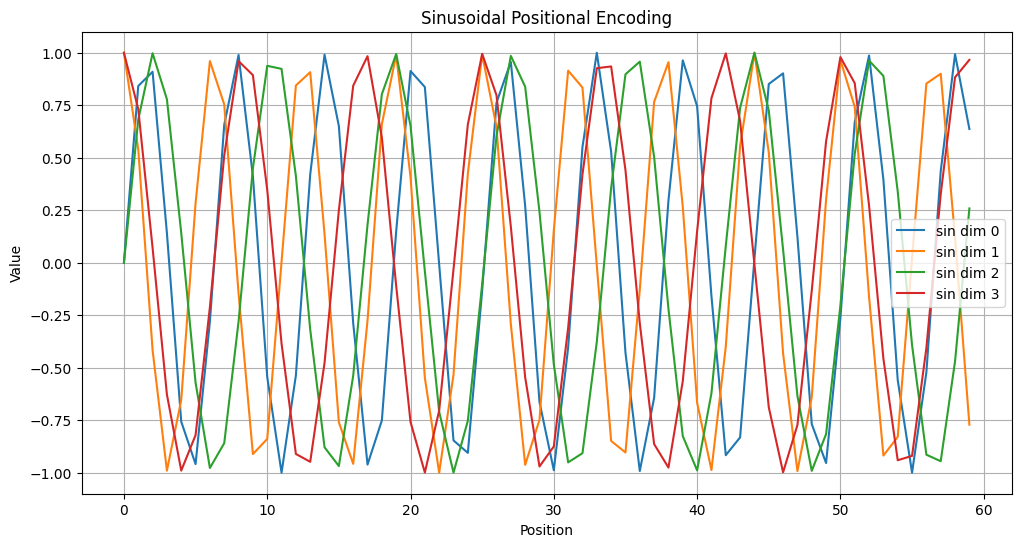

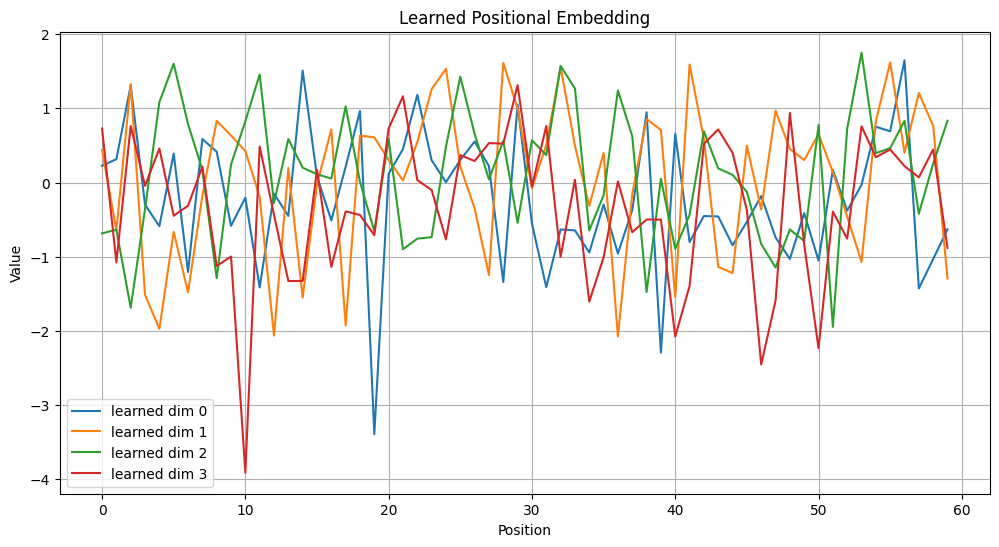

Sample sinusoidal values at first 5 positions, first 6 dims:
tensor([[ 0.0000,  1.0000,  0.0000,  1.0000,  0.0000,  1.0000],
        [ 0.8415,  0.5403,  0.6816,  0.7318,  0.5332,  0.8460],
        [ 0.9093, -0.4161,  0.9975,  0.0709,  0.9021,  0.4315],
        [ 0.1411, -0.9900,  0.7783, -0.6279,  0.9933, -0.1160],
        [-0.7568, -0.6536,  0.1415, -0.9899,  0.7785, -0.6277]])

Sample learned embedding values at first 5 positions, first 6 dims:
tensor([[ 2.2584e-01,  4.3770e-01, -6.8550e-01,  7.2858e-01, -1.3222e+00,
          2.4808e+00],
        [ 3.1505e-01, -6.4422e-01, -6.3675e-01, -1.0772e+00,  9.4547e-01,
         -8.5405e-04],
        [ 1.3089e+00,  1.3280e+00, -1.6882e+00,  7.6107e-01,  1.7885e+00,
          1.4204e+00],
        [-2.9858e-01, -1.5157e+00, -3.5759e-01, -4.5229e-02,  8.8034e-01,
          3.1096e-01],
        [-5.8914e-01, -1.9725e+00,  1.0847e+00,  4.5904e-01,  3.6713e-01,
         -7.8172e-01]])

--- Testing different input lengths ---
Input length =   5 | I

In [2]:
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)  # [max_len, d_model]
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)  # [max_len, 1]

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )  # [d_model/2]

        pe[:, 0::2] = torch.sin(position * div_term)  # even indices
        pe[:, 1::2] = torch.cos(position * div_term)  # odd indices

        pe = pe.unsqueeze(0)  # [1, max_len, d_model]
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class LearnedPositionalEmbedding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(LearnedPositionalEmbedding, self).__init__()
        self.embedding = nn.Embedding(max_len, d_model)

    def forward(self, x):
        batch_size, seq_len, d_model = x.shape
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0).expand(batch_size, seq_len)
        pos_embed = self.embedding(positions)
        return x + pos_embed


def print_encoding_rows(pos_encoder, num_rows=6, num_dims=8):
    print("\n--- First few rows of sinusoidal positional encoding matrix ---")
    pe_matrix = pos_encoder.pe[0]  # [max_len, d_model]
    print(pe_matrix[:num_rows, :num_dims])


def visualize_sinusoidal_encoding(pos_encoder, dims_to_plot=[0, 1, 2, 3, 10, 11], num_positions=100):
    pe_matrix = pos_encoder.pe[0][:num_positions].detach().cpu()

    plt.figure(figsize=(12, 6))
    for dim in dims_to_plot:
        plt.plot(pe_matrix[:, dim], label=f"dim {dim}")

    plt.title("Sinusoidal Positional Encoding Across Positions")
    plt.xlabel("Position")
    plt.ylabel("Encoding Value")
    plt.legend()
    plt.grid(True)
    plt.show()


def compare_with_learned_embeddings(d_model=64, seq_len=50, batch_size=1, max_len=500):
    print("\n--- Comparing sinusoidal encoding with learned positional embeddings ---")

    x = torch.zeros(batch_size, seq_len, d_model)

    sinusoidal = PositionalEncoding(d_model=d_model, max_len=max_len, dropout=0.0)
    learned = LearnedPositionalEmbedding(d_model=d_model, max_len=max_len)

    sinusoidal_out = sinusoidal(x)[0].detach().cpu()  # [seq_len, d_model]
    learned_out = learned(x)[0].detach().cpu()        # [seq_len, d_model]

    dims_to_plot = [0, 1, 2, 3]

    plt.figure(figsize=(12, 6))
    for dim in dims_to_plot:
        plt.plot(sinusoidal_out[:, dim], label=f"sin dim {dim}")
    plt.title("Sinusoidal Positional Encoding")
    plt.xlabel("Position")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 6))
    for dim in dims_to_plot:
        plt.plot(learned_out[:, dim], label=f"learned dim {dim}")
    plt.title("Learned Positional Embedding")
    plt.xlabel("Position")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.show()

    print("Sample sinusoidal values at first 5 positions, first 6 dims:")
    print(sinusoidal_out[:5, :6])

    print("\nSample learned embedding values at first 5 positions, first 6 dims:")
    print(learned_out[:5, :6])


def test_variable_input_lengths(d_model=128, batch_size=2, lengths=[5, 10, 25, 100]):
    print("\n--- Testing different input lengths ---")
    pos_encoder = PositionalEncoding(d_model=d_model, max_len=500, dropout=0.0)

    for seq_len in lengths:
        x = torch.zeros(batch_size, seq_len, d_model)
        out = pos_encoder(x)
        print(f"Input length = {seq_len:3d} | Input shape = {x.shape} | Output shape = {out.shape}")


if __name__ == "__main__":
    d_model = 64
    max_len = 200

    pos_encoder = PositionalEncoding(d_model=d_model, max_len=max_len, dropout=0.0)

    # 1. Print a few rows of the encoding matrix
    print_encoding_rows(pos_encoder, num_rows=8, num_dims=10)

    # 2. Visualize several dimensions
    visualize_sinusoidal_encoding(
        pos_encoder,
        dims_to_plot=[0, 1, 2, 3, 8, 9],
        num_positions=100
    )

    # 3. Compare sinusoidal encoding with learned embeddings
    compare_with_learned_embeddings(d_model=64, seq_len=60, batch_size=1, max_len=200)

    # 4. Test variable input lengths
    test_variable_input_lengths(d_model=64, batch_size=2, lengths=[5, 10, 20, 50, 120])